In [11]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os, sys
from scipy.interpolate import RectBivariateSpline
import pandas as pd
import sys
from matplotlib.ticker import FormatStrFormatter
import matplotlib

In [2]:
def read_in_completeness_period(inputgrid, verbose=False):
    hdulist = fits.open(inputgrid)
    cumulative_array = hdulist[0].data
    kiclist = np.asarray(hdulist[1].data, dtype=np.int32)
    probdet = np.transpose(cumulative_array[0])
    probtot = np.transpose(cumulative_array[1])
    prihdr = hdulist[0].header
    min_comp_period = prihdr["MINPER"]
    max_comp_period = prihdr["MAXPER"]
    n_comp_period = prihdr["NPER"]
    min_comp_rp = prihdr["MINRP"]
    max_comp_rp = prihdr["MAXRP"]
    n_comp_rp = prihdr["NRP"]
    hdulist.close()
    rp_want = np.linspace(min_comp_rp, max_comp_rp, n_comp_rp)
    period_want = np.linspace(min_comp_period, max_comp_period, n_comp_period)
    period_want2d, rp_want2d = np.meshgrid(period_want, rp_want, indexing='ij')
    numCompVeInterp = RectBivariateSpline(period_want, rp_want, probtot)
    if verbose:
        print(f"Min Period: {min_comp_period}\nMax Period: \
            {max_comp_period}\nSize:{n_comp_period}")
        print(f"Min Radius: {min_comp_rp}\nMax Radius: \
            {max_comp_rp}\nSize:{n_comp_rp}")
    return(numCompVeInterp, kiclist, probtot, probdet, probdet/probtot)

Min Period: 50.0
Max Period:             400.0
Size:2000
Min Radius: 0.75
Max Radius:             12.0
Size:3001


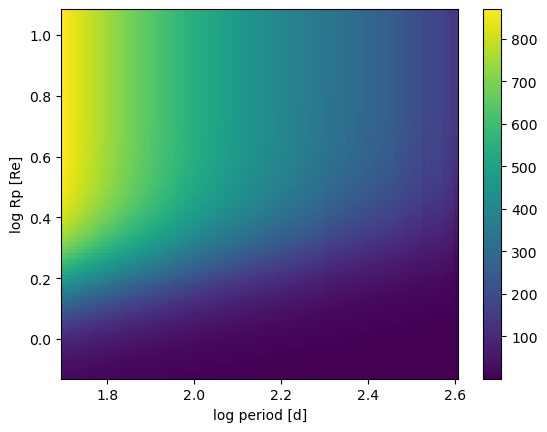

In [23]:
numCompVeInterp_FGK, kiclist_FGK, probtot, probdet, ratio = read_in_completeness_period(\
                                                               os.getcwd() + "/completenessContours/out_sc0_GK_baseline.fits.gz",\
                                                               verbose=True)

x = np.linspace(np.log10(50), np.log10(400), num=100)
y = np.linspace(np.log10(0.75), np.log10(12), num=100)
xg, yg = np.meshgrid(x, y, indexing='ij')


summedCompleteness = numCompVeInterp_FGK(10**x, 10**y)
summedCompleteness[np.where(summedCompleteness <= 0)] = np.nan
plt.figure()
plt.pcolormesh(xg, yg, summedCompleteness)
plt.colorbar()
plt.xlabel('log period [d]')
plt.ylabel('log Rp [Re]')
plt.show()

# probtot[-1], probdet[-1], ratio[-1]

In [10]:
x = np.linspace(np.log10(1), np.log10(400), num=501)
y = np.linspace(np.log10(0.5), np.log10(15), num=501)

In [13]:
# small grid for plotting
mr = np.logspace(np.log10(0.5), np.log10(15), num=9)
mp = np.logspace(np.log10(1.), np.log10(400), num=8)
mp_grid, mr_grid = np.meshgrid(mp, mr, indexing='ij')

mp_c = 0.5*(mp[1:] + mp[:-1])
mr_c = 0.5*(mr[1:] + mr[:-1])

In [20]:
# for later (:
def kde_anywhere(Z, pmin, pmax, rmin, rmax):
    pmask = (np.where((x >= np.log10(pmin)) & (x <= np.log10(pmax)))[0][0], 
            np.where((x >= np.log10(pmin)) & (x <= np.log10(pmax)))[0][-1])
    rmask = (np.where((y >= np.log10(rmin)) & (y <= np.log10(rmax)))[0][0], 
            np.where((y >= np.log10(rmin)) & (y <= np.log10(rmax)))[0][-1])
    return(Z[pmask[0]:pmask[1]+1, rmask[0]:rmask[1]+1])

In [24]:
inputgrid_FGK = os.getcwd() + "/completenessContours/out_sc0_GK_baseline.fits.gz"

hdulist = fits.open(inputgrid_FGK)
cumulative_array = hdulist[0].data
kiclist_FGK = np.asarray(hdulist[1].data, dtype=np.int32)
probtot_FGK = np.transpose(cumulative_array[1])
probdet_FGK = np.transpose(cumulative_array[0])
prihdr = hdulist[0].header
min_comp_period = prihdr["MINPER"]
max_comp_period = prihdr["MAXPER"]
n_comp_period = prihdr["NPER"]
min_comp_rp = prihdr["MINRP"]
max_comp_rp = prihdr["MAXRP"]
n_comp_rp = prihdr["NRP"]

# set up grid that the contour was calculated on
period_want = np.linspace(min_comp_period, max_comp_period, n_comp_period)
rp_want = np.linspace(min_comp_rp, max_comp_rp, n_comp_rp)
period_want2d, rp_want2d = np.meshgrid(period_want, rp_want)

# interpolate that shit
numCompVeInterp = RectBivariateSpline(period_want, rp_want, probtot_FGK)
sC_fine_FGK = numCompVeInterp(10**x, 10**y)
sC_fine_FGK[sC_fine_FGK < 0] = 0.0

# set low-completeness limits
limit = np.array([10., 50., 100.])
xl = np.linspace(1.0, 400., num=2000)
yl = np.linspace(0.1, 15., num=3001)
xlg, ylg = np.meshgrid(xl, yl, indexing='ij')
cs = plt.contour(xlg, ylg, probtot_FGK/kiclist_FGK.size, levels=limit/kiclist_FGK.size, colors='k')
xlim_FGK = cs.collections[1].get_paths()[0].vertices[:, 0]
ylim_FGK = cs.collections[1].get_paths()[0].vertices[:, 1]
plt.close()



In [26]:
pcCatalog_FGK = os.getcwd() + "/GKbaseline/koiCatalogs/dr25_{}_PCs.csv".format('GK')

# load in planet candidates
base_kois = pd.read_csv(pcCatalog_FGK)
m = (1 <= base_kois.koi_period) & (base_kois.koi_period <= 500)
m &= np.isfinite(base_kois.corrected_prad) & (0.4 <= base_kois.corrected_prad) & (base_kois.corrected_prad <= 22)
    
kois_FGK = pd.DataFrame(base_kois[m])

# create 2D histogram
H_FGK, xedges, yedges = np.histogram2d(kois_FGK.koi_period, kois_FGK.corrected_prad, bins=(mp, mr))
H_nan_FGK = H_FGK * 1
H_nan_FGK[H_nan_FGK < 1] = np.nan

# this sets up where the low completeness limit is
H_lim_FGK = np.zeros(H_FGK.shape)
for i in range(len(xedges)-1):
    for j in range(len(yedges)-1):
        H_lim_FGK[i, j] = ylim_FGK[np.where(xlim_FGK <= xedges[i])][0] > yedges[j]

In [42]:
boot_kde = np.load("sboot__1000.npy")
boot_kde_FGK, boot_kde_FGK_err = np.mean(boot_kde, axis = 0), np.std(boot_kde, axis = 0)
boot_kde_smol_FGK = np.zeros((len(mp)-1, len(mr)-1))
boot_kde_smol_err_FGK = np.zeros((len(mp)-1, len(mr)-1))

# go forth and propagate

for i in range(len(mp)-1):
    for j in range(len(mr)-1):
        z = kde_anywhere(boot_kde_FGK/sC_fine_FGK, mp[i], mp[i+1], mr[j], mr[j+1])
        boot_kde_smol_FGK[i, j] = np.sum(z)*(np.diff(x)[0]*np.diff(y)[0])
        
        z_e = np.sum(kde_anywhere(boot_kde_err_FGK, mp[i], mp[i+1], mr[j], mr[j+1]))/np.sum(
                    kde_anywhere(boot_kde_FGK, mp[i], mp[i+1], mr[j], mr[j+1]))
        
        boot_kde_smol_err_FGK[i, j] = np.sqrt(z_e**2)*boot_kde_smol_FGK[i, j]

# we don't want to plot cells that had no planet detections ! 
boot_kde_smol_FGK_nan = boot_kde_smol_FGK.copy()
boot_kde_smol_FGK_nan[H_FGK < 1] = np.nan
boot_kde_smol_FGK_nan[H_lim_FGK >= 1] = np.nan

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# make a nice plot!
fig, ax = plt.subplots(num=4, figsize=(12, 7))
hatch = plt.fill_between([np.log10(1),np.log10(400)], 
                         np.log10(0.5), np.log10(15), color="lightgray")

im = ax.pcolormesh(np.log10(mp_grid), np.log10(mr_grid), boot_kde_smol_FGK_nan*100, 
                   cmap='magma', norm=matplotlib.colors.LogNorm(vmin=1e-2, vmax=15), shading='flat',
                   edgecolor='white', linewidth=0.5)

for i in range(len(yedges)-1):
    for j in range(len(xedges)-1):
        if boot_kde_smol_FGK.T[i,j]*100>=10:
            o = '%.3f' % (boot_kde_smol_FGK*100).T[i,j]
            e = '%.2f' % (boot_kde_smol_err_FGK*100).T[i,j]
            t =  o + "\n± " + e
        else:
            o = '%.4f' % (boot_kde_smol_FGK*100).T[i,j]
            e = '%.3f' % (boot_kde_smol_err_FGK*100).T[i,j]
            t =  o + "\n± " + e
        if np.isnan(H_nan_FGK.T[i,j]):
            o = '%.3f' %((boot_kde_smol_FGK*100).T[i,j]+(boot_kde_smol_err_FGK*100).T[i,j])
            ax.text(np.log10(mp_c[j])-0.03, np.log10(mr_c[i]), "< "+str(o), 
                color="k", ha="center", va="center", fontsize=14)
        elif H_lim_FGK.T[i,j]:
            o = '%.3f' %((boot_kde_smol_FGK*100).T[i,j]+(boot_kde_smol_err_FGK*100).T[i,j])
            ax.text(np.log10(mp_c[j])-0.03, np.log10(mr_c[i]), "< "+str(o), 
                color="k", ha="center", va="center", fontsize=14)
        elif boot_kde_smol_FGK.T[i,j]>=0.045:
            ax.text(np.log10(mp_c[j])-0.03, np.log10(mr_c[i]), t, 
                color="k", ha="center", va="center", fontsize=14)
        else:
            ax.text(np.log10(mp_c[j])-0.03, np.log10(mr_c[i]), t, 
                color="white", ha="center", va="center", fontsize=14)

ax.tick_params(axis='both', labelsize='large')
cb = plt.colorbar(im)
cb.set_label(label="Number of planets per 100 stars", fontsize=18)

plt.xlim(np.log10(1.), np.log10(400.))
plt.ylim(np.log10(0.5), np.log10(16.))

plt.xlabel("Period (days)", fontsize=18)
plt.ylabel(r"Radius (R$_\oplus$)", fontsize=18)
plt.xticks(np.log10(mp), labels=[1.0, 2.11, 4.47, 9.46, 20.0, 42.29, 89.44 ,189.15, 400.0])
plt.yticks(np.log10(mr), labels=[ 0.5, 0.73, 1.08, 1.59, 2.33, 3.43, 5.04, 7.41, 10.89, 16.0])
plt.minorticks_off()
plt.tight_layout()
plt.show()